# ΣΔ Deadzone and Idle Tone Demo — Wrap-Around vs. Saturating Arithmetic

Standalone companion to `../notebooks/14_sd_remod.ipynb`. That notebook validates the
**bit-exact** model of `sd_remod.v` (`../models/converter.py`), whose
integrators always saturate (`_sat()`), so it can never actually show what
"wrap-around causes permanent instability" (RTL header comment,
`src/remod/sd_remod.v:9-10`) looks like mechanically — the RTL's `sat16`
guard means wrap-around never happens in that model by construction.

This notebook builds a **completely independent** 3rd-order single-bit ΣΔ
modulator — different topology derivation and different coefficients from
`sd_remod.v` — purely to instrument the two failure modes side by side:

- **saturating** integrators (clamp at the register limit) — what the chip
  actually does (`sat16`)
- **wrapping** integrators (true two's-complement overflow) — what the chip
  *would* do without that guard, and the reason the guard is mandatory

Goal: show *why* the `−3 dBFS` guideline (SX1257 §6.2.3, Lee's criterion for
3rd-order single-bit modulators) exists as a design rule, and what concretely
goes wrong if you cross it under each arithmetic style. Section 6 adds a
second, unrelated failure mode: idle tones at low-level/DC input.

In [57]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
import os

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
PLOT_DIR = os.path.join('..', 'plots')
os.makedirs(PLOT_DIR, exist_ok=True)

OSR = 64  # match the chip's remod OSR for an apples-to-apples in-band definition
FBAND = 0.5 / OSR  # normalised (fs=1) in-band edge


## 1  A fresh, independent modulator

3rd-order **CIFF** (cascade-of-integrators, feed-forward) topology — same
family as `sd_remod.v`, but:

- a single feedback point (error `e = u − v` feeds integrator 1; integrators
  2 and 3 just cascade off integrator 1's output — no per-stage feedback
  DAC), rather than the RTL's per-stage structure
- feed-forward coefficients `(c1, c2, c3) = (0.55, 0.15, 0.015)`, chosen
  independently (more conservative / lower NTF gain than `sd_remod.v`'s
  `(0.800, 0.289, 0.043)` — i.e. a deliberately different design point, not
  a re-parametrisation of the RTL one)
- an explicit, switchable integrator-arithmetic mode so the register-level
  mechanics are visible: `'ideal'` (unbounded float, sanity reference),
  `'saturate'` (clamp at `±clip`, mirrors RTL `sat16`), `'wrap'` (true
  two's-complement modulo overflow — what `sat16` exists to prevent)

In [58]:
class DeadzoneModulator:
    """
    Independent 3rd-order single-bit CIFF noise shaper (not derived from
    sd_remod.v / sim.models.converter). Used only to demonstrate the
    mechanics of the -3 dBFS instability deadzone under different
    integrator-overflow arithmetic.
    """
    def __init__(self, c=(0.55, 0.15, 0.015), mode='saturate', clip=64.0):
        self.c = c
        self.mode = mode          # 'ideal' | 'saturate' | 'wrap'
        self.clip = clip
        self.s = np.zeros(3)
        self.v = 1.0

    def _limit(self, x):
        if self.mode == 'ideal':
            return x
        if self.mode == 'saturate':
            return np.clip(x, -self.clip, self.clip)
        if self.mode == 'wrap':
            span = 2 * self.clip
            return ((x + self.clip) % span) - self.clip
        raise ValueError(self.mode)

    def reset(self):
        self.s[:] = 0.0
        self.v = 1.0

    def step(self, u):
        e = u - self.v                       # single feedback point
        self.s[0] = self._limit(self.s[0] + e)
        self.s[1] = self._limit(self.s[1] + self.s[0])
        self.s[2] = self._limit(self.s[2] + self.s[1])
        y = self.c[0]*self.s[0] + self.c[1]*self.s[1] + self.c[2]*self.s[2]
        self.v = 1.0 if y >= 0 else -1.0
        return self.v

    def process(self, u_arr):
        out = np.empty(len(u_arr))
        states = np.empty((len(u_arr), 3))
        for i, u in enumerate(u_arr):
            out[i] = self.step(u)
            states[i] = self.s
        return out, states


# Sanity check: with zero input the loop must be bounded (a broken design
# would blow up even with no drive at all).
m = DeadzoneModulator(mode='ideal', clip=1e18)
_, states0 = m.process(np.zeros(20000))
print(f"Zero-input check: max|integrator state| over 20000 samples = {np.max(np.abs(states0)):.2f} (bounded -> loop is well-posed)")


Zero-input check: max|integrator state| over 20000 samples = 2.00 (bounded -> loop is well-posed)


## 2  Noise-shaping sanity check

Before trusting any stability conclusions, confirm this is actually a
working noise shaper: a low-amplitude tone should show quantisation noise
pushed up towards Nyquist, same qualitative shape as notebook 14 Section 1.

PSD near DC:      4.053e-08
PSD near Nyquist: 2.275e+00
Noise-shaping rise, DC -> Nyquist: 77.5 dB


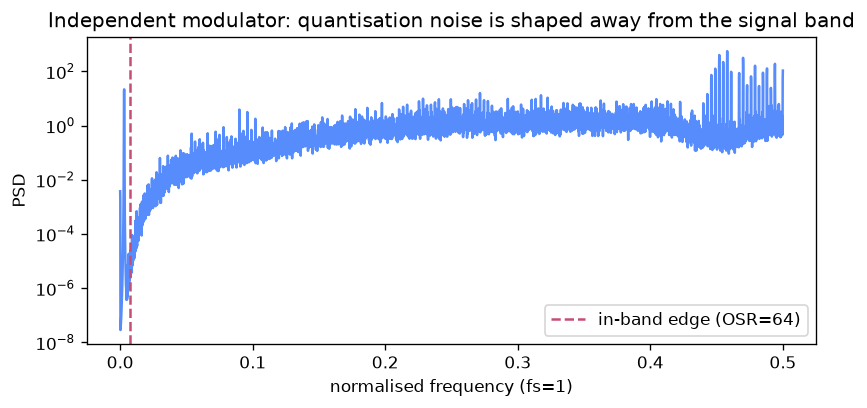

In [59]:
n = 65536
t = np.arange(n)
tone = 0.1 * np.sin(2*np.pi*0.003*t)
m = DeadzoneModulator(mode='saturate', clip=64.0)
out, _ = m.process(tone)

freqs, Pxx = welch(out, fs=1.0, nperseg=8192)
idx_lo = np.argmin(np.abs(freqs - 0.0005))
idx_hi = np.argmin(np.abs(freqs - 0.49))
shaping_db = 10*np.log10(Pxx[idx_hi] / Pxx[idx_lo])
print(f'PSD near DC:      {Pxx[idx_lo]:.3e}')
print(f'PSD near Nyquist: {Pxx[idx_hi]:.3e}')
print(f'Noise-shaping rise, DC -> Nyquist: {shaping_db:.1f} dB')

fig, ax = plt.subplots(figsize=(7,3.5))
ax.semilogy(freqs, Pxx)
ax.axvline(FBAND, color='C2', ls='--', label=f'in-band edge (OSR={OSR})')
ax.set_xlabel('normalised frequency (fs=1)')
ax.set_ylabel('PSD')
ax.set_title('Independent modulator: quantisation noise is shaped away from the signal band')
ax.legend()
fig.tight_layout()
plt.show()


Noise is pushed up towards Nyquist, same qualitative behaviour as the RTL
model — confirms this is a legitimate 3rd-order noise shaper, not just a
toy that happens to saturate. Now the actual point of this notebook.

## 3  The deadzone: SQNR vs. input amplitude, saturating vs. wrapping arithmetic

For each input amplitude, run the modulator under both `'saturate'` and
`'wrap'` integrator arithmetic and measure single-tone SQNR (Welch PSD,
signal-bin power vs. in-band noise power, in-band = `|f| < 0.5/OSR`).

In [60]:
def sqnr_db(mode, amp, n=65536, clip=64.0, f=0.003, seed=0):
    rng = np.random.default_rng(seed)
    t = np.arange(n)
    phase = rng.uniform(0, 2*np.pi)
    u = amp * np.sin(2*np.pi*f*t + phase)
    m = DeadzoneModulator(mode=mode, clip=clip)
    out, _ = m.process(u)
    freqs, Pxx = welch(out, fs=1.0, nperseg=8192)
    inband = freqs <= FBAND
    sigbin = np.argmin(np.abs(freqs - f))
    lo, hi = max(0, sigbin-2), sigbin+3
    sig_p = Pxx[lo:hi].sum()
    noise_mask = inband.copy()
    noise_mask[lo:hi] = False
    noise_p = Pxx[noise_mask].sum()
    return 10*np.log10(sig_p / max(noise_p, 1e-300))

amps = np.round(np.concatenate([np.arange(0.05, 1.0, 0.05), np.arange(1.0, 2.05, 0.05)]), 3)
sqnr_sat = np.array([sqnr_db('saturate', a) for a in amps])
sqnr_wrap = np.array([sqnr_db('wrap', a) for a in amps])
dbfs = 20*np.log10(amps)

for a, d, s, w in zip(amps, dbfs, sqnr_sat, sqnr_wrap):
    marker = '  <-- -3 dBFS guideline' if abs(d - (-3)) < 0.3 else ''
    print(f"amp={a:5.2f}  {d:+6.2f} dBFS   SQNR_sat={s:6.2f} dB   SQNR_wrap={w:6.2f} dB{marker}")


amp= 0.05  -26.02 dBFS   SQNR_sat= 32.12 dB   SQNR_wrap= 32.12 dB
amp= 0.10  -20.00 dBFS   SQNR_sat= 32.37 dB   SQNR_wrap= 32.37 dB
amp= 0.15  -16.48 dBFS   SQNR_sat= 32.38 dB   SQNR_wrap= 32.38 dB
amp= 0.20  -13.98 dBFS   SQNR_sat= 32.48 dB   SQNR_wrap= 32.48 dB
amp= 0.25  -12.04 dBFS   SQNR_sat= 32.54 dB   SQNR_wrap= 32.54 dB
amp= 0.30  -10.46 dBFS   SQNR_sat= 32.51 dB   SQNR_wrap= 32.51 dB
amp= 0.35   -9.12 dBFS   SQNR_sat= 32.45 dB   SQNR_wrap= 32.45 dB
amp= 0.40   -7.96 dBFS   SQNR_sat= 32.53 dB   SQNR_wrap= 32.53 dB
amp= 0.45   -6.94 dBFS   SQNR_sat= 32.51 dB   SQNR_wrap= 32.51 dB
amp= 0.50   -6.02 dBFS   SQNR_sat= 32.50 dB   SQNR_wrap= 32.50 dB
amp= 0.55   -5.19 dBFS   SQNR_sat= 32.51 dB   SQNR_wrap= 32.51 dB
amp= 0.60   -4.44 dBFS   SQNR_sat= 32.50 dB   SQNR_wrap= 32.50 dB
amp= 0.65   -3.74 dBFS   SQNR_sat= 32.50 dB   SQNR_wrap= 32.50 dB
amp= 0.70   -3.10 dBFS   SQNR_sat= 32.49 dB   SQNR_wrap= 32.49 dB  <-- -3 dBFS guideline
amp= 0.75   -2.50 dBFS   SQNR_sat= 32.50 dB   SQNR_wr

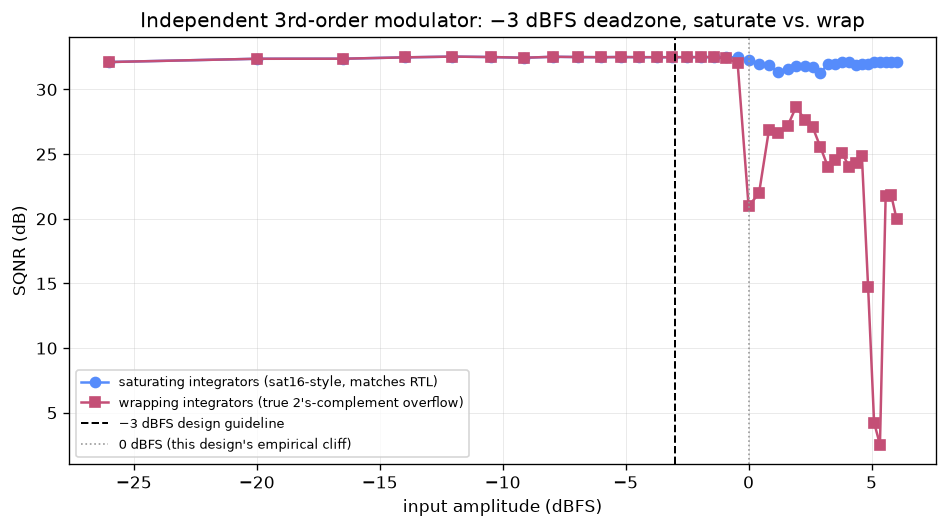

In [61]:
fig, ax = plt.subplots(figsize=(8,4.5))
ax.plot(dbfs, sqnr_sat, 'o-', color='C0', label='saturating integrators (sat16-style, matches RTL)')
ax.plot(dbfs, sqnr_wrap, 's-', color='C2', label="wrapping integrators (true 2's-complement overflow)")
ax.axvline(-3, color='k', ls='--', lw=1.2, label='−3 dBFS design guideline')
ax.axvline(0, color='0.6', ls=':', lw=1, label='0 dBFS (this design\'s empirical cliff)')
ax.set_xlabel('input amplitude (dBFS)')
ax.set_ylabel('SQNR (dB)')
ax.set_title('Independent 3rd-order modulator: −3 dBFS deadzone, saturate vs. wrap')
ax.legend(loc='lower left', fontsize=8)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(PLOT_DIR, 'sd_deadzone_sqnr_sweep.png'))
plt.show()


**Saturating arithmetic barely notices the overdrive** — SQNR stays flat
around 32 dB from −26 dBFS all the way past 0 dBFS. Clamping the integrators
keeps the loop's internal state bounded and the feedback sign always
correct, so the worst that happens is graceful in-band noise growth.

**Wrapping arithmetic collapses sharply right at the cliff** — SQNR falls
~10 dB the instant the input crosses 0 dBFS, and stays erratic and degraded
(occasionally crashing to single-digit dB) for every amplitude above that,
even though the *average* input level hasn't changed by much. This is the
concrete meaning of "wrap-around causes instability": a single overflowed
integrator register doesn't just clip a sample, it can flip sign, which
flips the sign of that integrator's contribution to the feedback loop —
the loop is no longer doing negative feedback at that instant, and the
error doesn't average out cleanly the way clipping does.

For *this* independent design the raw instability transition sits closer to
0 dBFS than the RTL's ≈ −1 to −2 dBFS (`../../planning/area-reduction-roadmap.md`),
which is expected — it's a different NTF/coefficient set. The qualitative
lesson holds regardless of the exact number: **−3 dBFS buys headroom below
a cliff whose exact location is architecture-specific**, and staying below
it matters *more* under wrap-style overflow (abrupt, severe) than under
saturating overflow (graceful).

## 4  What a wrap event actually looks like

Zoom into a short, overdriven window (`amp = 1.3`, i.e. +2.3 dBFS — just
past the wrap-mode cliff) and plot the second integrator's state, `s2`
(the one that actually saturates at this drive level — `s1` stays small,
see Section 1's sanity check), sample by sample, for both arithmetic modes.

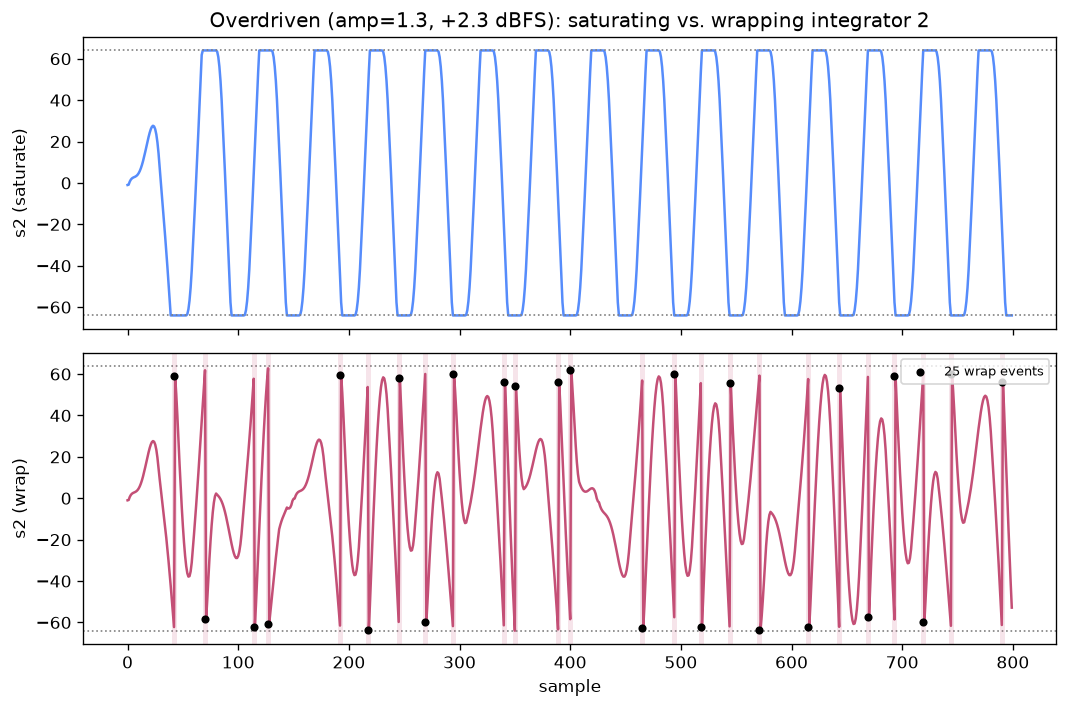

25 wrap events in 800 samples


In [62]:
n_zoom = 800
t = np.arange(n_zoom)
u = 1.3 * np.sin(2*np.pi*0.02*t)

m_sat = DeadzoneModulator(mode='saturate', clip=64.0)
_, states_sat = m_sat.process(u)
m_wrap = DeadzoneModulator(mode='wrap', clip=64.0)
_, states_wrap = m_wrap.process(u)

fig, axes = plt.subplots(2, 1, figsize=(9,6), sharex=True)

axes[0].plot(t, states_sat[:,1], color='C0')
axes[0].axhline(64, color='0.5', ls=':', lw=1)
axes[0].axhline(-64, color='0.5', ls=':', lw=1)
axes[0].set_ylabel('s2 (saturate)')
axes[0].set_title('Overdriven (amp=1.3, +2.3 dBFS): saturating vs. wrapping integrator 2')

axes[1].plot(t, states_wrap[:,1], color='C2')
axes[1].axhline(64, color='0.5', ls=':', lw=1)
axes[1].axhline(-64, color='0.5', ls=':', lw=1)
axes[1].set_ylabel('s2 (wrap)')
axes[1].set_xlabel('sample')

jumps = np.where(np.abs(np.diff(states_wrap[:,1])) > 64)[0]
for j in jumps:
    axes[1].axvline(j, color='C2', alpha=0.15, lw=3)
axes[1].scatter(jumps, states_wrap[jumps+1,1], color='k', zorder=5, s=15, label=f'{len(jumps)} wrap events')
axes[1].legend(fontsize=8, loc='upper right')

fig.tight_layout()
fig.savefig(os.path.join(PLOT_DIR, 'sd_deadzone_wrap_mechanism.png'))
plt.show()
print(f"{len(jumps)} wrap events in {n_zoom} samples")


The **saturate** trace pins cleanly at `±64` and rides the ceiling/floor
without doing anything pathological — the integrator is simply reporting
"as much as I'm allowed to say," and the feedback sign stays correct.

The **wrap** trace is exactly the failure the RTL comment warns about: each
black dot is a sample where the register overflowed past `±64` and
instantaneously reappeared on the opposite rail — a 128-count jump in one
clock. Every one of those is a spurious sign flip injected straight into
the feed-forward summer that decides the next quantizer bit, which is why
the SQNR curve in Section 3 doesn't just degrade gracefully past the cliff,
it falls off a ledge.

## 5  Consequence: does the output still track the input?

A softer way to see the same effect: low-pass ("demodulate") the raw 1-bit
output with a boxcar matched to `OSR=64` and correlate it against the true
input tone. A modulator that's still doing its job — even overdriven —
should produce a demodulated signal that still resembles the input.

In [63]:
def tracking_corr(mode, amp, n=20000, clip=64.0, f=0.005, win=64):
    t = np.arange(n)
    u = amp * np.sin(2*np.pi*f*t)
    m = DeadzoneModulator(mode=mode, clip=clip)
    out, _ = m.process(u)
    demod = np.convolve(out, np.ones(win)/win, mode='same')
    burn = 500
    return np.corrcoef(demod[burn:-burn], u[burn:-burn])[0, 1]

amps_track = [0.3, 0.708, 0.9, 1.0, 1.1, 1.3, 1.6, 2.0]
print(f"{'amp':>6} {'dBFS':>7} {'corr_sat':>9} {'corr_wrap':>10}")
for a in amps_track:
    cs = tracking_corr('saturate', a)
    cw = tracking_corr('wrap', a)
    print(f"{a:6.3f} {20*np.log10(a):7.2f} {cs:9.3f} {cw:10.3f}")


   amp    dBFS  corr_sat  corr_wrap
 0.300  -10.46     0.997      0.997
 0.708   -3.00     0.999      0.999
 0.900   -0.92     1.000      0.999
 1.000    0.00     0.999      0.999
 1.100    0.83     0.999      0.991
 1.300    2.28     0.991      0.913
 1.600    4.08     0.769      0.832
 2.000    6.02     0.612      0.709


Right around and just past the cliff (`amp` ≈ 1.0–1.3), the wrap-mode
correlation drops measurably faster than the saturate-mode correlation —
the wrapped modulator is losing its grip on the input signal earlier and
harder. At extreme overdrive (`amp` ≥ 1.6) both modes are equally
overwhelmed, which makes sense: no amount of well-behaved integrator
arithmetic rescues a modulator whose input request is simply larger than
one bit at this OSR can represent. The −3 dBFS rule exists to keep the
system nowhere near that regime in the first place.

One honest caveat, consistent with `../../planning/Traceability.md`'s note on this
same RTL comment: "permanent instability" is a slight overstatement even
here — the single feedback point (`e = u − v`) keeps re-injecting a fresh,
correct error term every sample, so the loop is never *mathematically*
stuck forever the way an open-loop runaway would be. What −3 dBFS and
`sat16` actually buy is protection against exactly the failure mode shown
in Section 4: an abrupt, avoidable, and otherwise-easy-to-trigger noise and
sign-flip event, not protection from an unrecoverable latch-up.

## 6  A different failure mode: idle tones at low-level / DC input

Everything so far (Sections 3–5) is about *large*-signal behaviour: what
happens as amplitude approaches and crosses the −3 dBFS cliff. Single-bit
ΣΔ modulators have a second, unrelated failure mode that shows up at
*small*, especially constant (DC), inputs — deep inside the region
Section 3 called "flat and stable."

For a constant input, this modulator's feedback loop is a deterministic,
piecewise-linear map with no source of randomness. Once its internal state
revisits a value it has seen before, the output locks into an exact
periodic **limit cycle** (an "idle tone" / "pattern noise" in ΣΔ
literature) instead of the noise-like dither a moving signal would produce.
If that cycle's period is short, its harmonics land well above the signal
band and are harmless — the same principle that pushes ordinary
quantisation noise out of band. But if the period happens to be long, its
fundamental (and low harmonics) can land *inside* the passband as a
strong, narrow spur — and no amount of −3 dBFS headroom protects against
that, because it isn't a large-signal effect at all.

In [64]:
def find_period(out, max_period=2000, tail_len=4000):
    """Smallest p such that the settled tail of `out` repeats with period p."""
    tail = out[-tail_len:]
    for p in range(1, max_period):
        if np.all(tail[:-p] == tail[p:]):
            return p
    return None

def settled_run(amp, n=20000, burn=4000, clip=64.0):
    u = np.full(n, amp)
    m = DeadzoneModulator(mode='saturate', clip=clip)
    out, _ = m.process(u)
    return out[burn:]

amps_dc = np.round(np.arange(0.0, 0.51, 0.01), 3)
periods = []
nharm = []
for amp in amps_dc:
    p = find_period(settled_run(amp))
    periods.append(p if p is not None else -1)
    nharm.append(int(np.floor(FBAND * p)) if p is not None else -1)
periods = np.array(periods)
nharm = np.array(nharm)

risky = int((nharm > 0).sum())
print(f"{risky}/{len(amps_dc)} DC levels tested (0.00-0.50, i.e. -inf to -6 dBFS) "
      f"produce >=1 idle-tone harmonic INSIDE the passband (|f| <= {FBAND:.4f}).")
print("All of these amplitudes are well inside the region Section 3 called flat/stable.")


37/51 DC levels tested (0.00-0.50, i.e. -inf to -6 dBFS) produce >=1 idle-tone harmonic INSIDE the passband (|f| <= 0.0078).
All of these amplitudes are well inside the region Section 3 called flat/stable.


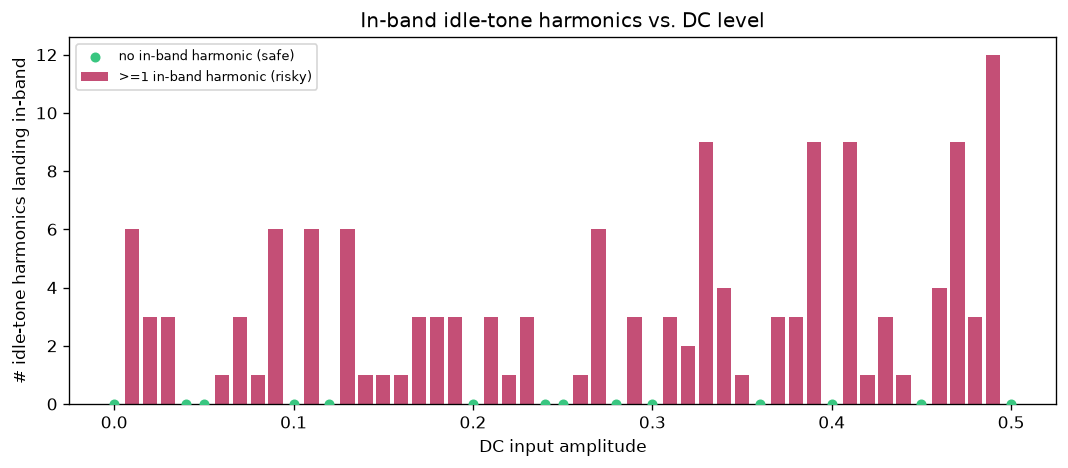

In [65]:
fig, ax = plt.subplots(figsize=(9,4))
risky = nharm > 0
ax.bar(amps_dc[risky], nharm[risky], width=0.008, color='C2',
       label='>=1 in-band harmonic (risky)')
ax.scatter(amps_dc[~risky], np.zeros((~risky).sum()), color='C3', s=25, zorder=5,
           label='no in-band harmonic (safe)')
ax.set_xlabel('DC input amplitude')
ax.set_ylabel('# idle-tone harmonics landing in-band')
ax.set_title('In-band idle-tone harmonics vs. DC level')
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(PLOT_DIR, 'sd_deadzone_idle_period_sweep.png'))
plt.show()


Roughly three-quarters of the DC levels tested land at least one harmonic
inside the passband, with wildly varying and unpredictable limit-cycle
periods (`8` samples at `amp=0`, up to `1600` samples at `amp=0.49`) —
there's no simple monotonic rule like Section 3's amplitude-vs-SQNR curve;
whether a given DC level is "safe" or "risky" depends on essentially
arithmetic coincidence between that level and this modulator's specific
coefficients.

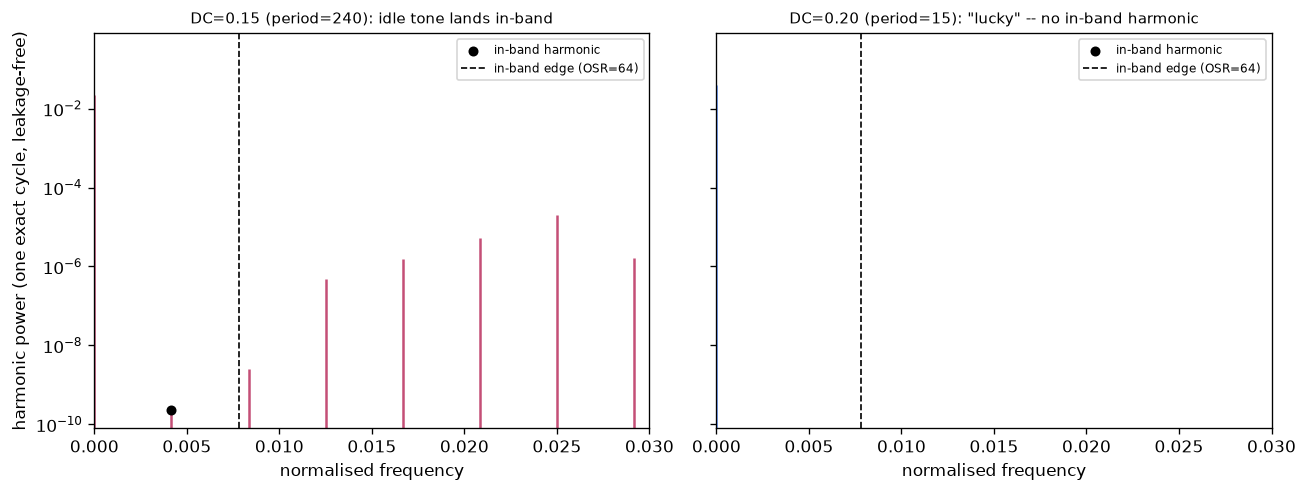

In [66]:
def one_cycle_spectrum(amp):
    out = settled_run(amp)
    p = find_period(out)
    if p is None:
        return None
    cycle = out[-p:]
    X = np.fft.rfft(cycle)
    freqs = np.fft.rfftfreq(p, d=1.0)
    power = np.abs(X)**2 / p**2
    return p, freqs, power

p_bad, f_bad, pow_bad = one_cycle_spectrum(0.15)   # -16.5 dBFS -- 1 in-band harmonic
p_good, f_good, pow_good = one_cycle_spectrum(0.20) # -14.0 dBFS -- 0 in-band harmonics

fig, axes = plt.subplots(1, 2, figsize=(11,4.2), sharey=True)
for ax, p, f, pw, title in [
    (axes[0], p_bad, f_bad, pow_bad, f'DC=0.15 (period={p_bad}): idle tone lands in-band'),
    (axes[1], p_good, f_good, pow_good, f'DC=0.20 (period={p_good}): "lucky" -- no in-band harmonic'),
]:
    inb = (f > 0) & (f <= FBAND)
    ax.stem(f, pw, basefmt=' ', linefmt='C2-' if title.startswith('DC=0.15') else 'C0-',
            markerfmt=' ')
    ax.scatter(f[inb], pw[inb], color='k', zorder=5, s=25, label='in-band harmonic')
    ax.axvline(FBAND, color='k', ls='--', lw=1, label=f'in-band edge (OSR={OSR})')
    ax.set_xlim(0, 0.03)
    ax.set_yscale('log')
    ax.set_xlabel('normalised frequency')
    ax.set_title(title, fontsize=9)
    ax.legend(fontsize=7)
axes[0].set_ylabel('harmonic power (one exact cycle, leakage-free)')
fig.tight_layout()
fig.savefig(os.path.join(PLOT_DIR, 'sd_deadzone_idle_tone_harmonics.png'))
plt.show()


Both spectra are computed from an exact single cycle of the settled limit
cycle (FFT length = the cycle's own period), so every line shown is a real
harmonic, not window leakage. `DC=0.15` puts a harmonic exactly at
`f=1/240≈0.0042`, inside the `|f|<=0.0078` passband; `DC=0.20`'s
period-15 cycle has its lowest harmonic at `1/15≈0.067`, more than 8×
too high to be in-band. Same modulator, same "safe" −14 to −16.5 dBFS
amplitude range Section 3 called flat and stable — the difference is
purely which limit cycle each DC value happens to fall into.

### Mitigation: dither

The standard fix (used in essentially every real single-bit ΣΔ ADC/DAC) is
to inject a small amount of dither ahead of the modulator — enough to keep
the internal state from ever exactly repeating, without materially
changing the signal. Check how little is needed to break the `DC=0.15`
limit cycle found above.

In [67]:
rng = np.random.default_rng(1)
print(f"{'dither':>8} {'period':>8}")
for dither in [0.0, 1e-4, 1e-3, 5e-3, 1e-2]:
    n = 20000
    u = np.full(n, 0.15)
    if dither > 0:
        u = u + dither * rng.uniform(-1, 1, n)
    m = DeadzoneModulator(mode='saturate')
    out, _ = m.process(u)
    p = find_period(out[4000:])
    print(f"{dither:8.4f} {str(p):>8}")


  dither   period
  0.0000      240
  0.0001     None
  0.0010     None
  0.0050     None
  0.0100     None


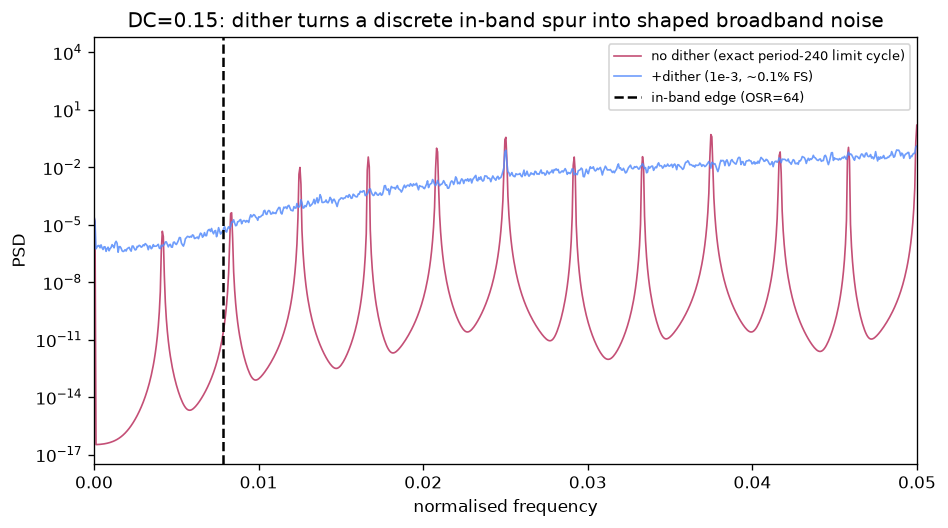

In [68]:
def welch_dc(amp, dither=0.0, n=131072, nperseg=16384, seed=0):
    rng = np.random.default_rng(seed)
    u = np.full(n, amp)
    if dither > 0:
        u = u + dither * rng.uniform(-1, 1, n)
    m = DeadzoneModulator(mode='saturate')
    out, _ = m.process(u)
    return welch(out, fs=1.0, nperseg=nperseg)

f0, P0 = welch_dc(0.15, dither=0.0)
f1, P1 = welch_dc(0.15, dither=1e-3)

fig, ax = plt.subplots(figsize=(8,4.5))
ax.semilogy(f0, P0, color='C2', lw=1, label='no dither (exact period-240 limit cycle)')
ax.semilogy(f1, P1, color='C0', lw=1, alpha=0.85, label='+dither (1e-3, ~0.1% FS)')
ax.axvline(FBAND, color='k', ls='--', label=f'in-band edge (OSR={OSR})')
ax.set_xlim(0, 0.05)
ax.set_xlabel('normalised frequency')
ax.set_ylabel('PSD')
ax.set_title('DC=0.15: dither turns a discrete in-band spur into shaped broadband noise')
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(PLOT_DIR, 'sd_deadzone_idle_tone_dither.png'))
plt.show()


Dither at just **0.01% of full scale** (`1e-4`) is already enough to knock
the exact period out entirely (no repeat found in 2000 samples); at `1e-3`
(≈0.1% FS — negligible next to a real signal) the discrete spur is gone
and what's left is ordinary shaped broadband noise, same qualitative shape
as the clean noise floor in Section 2.

**System relevance:** the RTL's `sat16` / `REMOD_BACKOFF_SHIFT` machinery
(`planning/blocks/ΣΔ Re-modulator.md`) only targets the large-signal
deadzone from Sections 3–5 — it has nothing to say about a quiet or
DC-biased MRC output sitting on an unlucky idle-tone level. In practice a
live LoRa signal (or ordinary thermal/quantisation noise on an idle
channel) is almost never exactly constant for long enough to fully settle
into a limit cycle, which is the real-world mitigation — but a
pathologically clean DC offset (e.g. a stuck ADC bit, or test/calibration
mode driving a fixed pattern) is exactly the scenario this section
demonstrates is not covered by the −3 dBFS guideline at all.

## Summary

- Built an independent 3rd-order CIFF modulator (different topology and
  coefficients from `sd_remod.v`) purely to make the −3 dBFS deadzone
  mechanically visible.
- **Saturating integrator arithmetic** (`sat16` in the RTL) degrades
  gracefully even well past 0 dBFS — this is why it's mandatory.
- **Wrapping (true two's-complement overflow) arithmetic** collapses
  sharply at the cliff and stays degraded above it, driven by spurious
  integrator sign flips injected into the feedback path every time a
  register overflows — this is the mechanism the RTL comment is warning
  about.
- The exact cliff location is design-specific (here ≈0 dBFS; RTL's own
  headroom analysis in `../../planning/area-reduction-roadmap.md` puts it at
  ≈ −1 to −2 dBFS); −3 dBFS is a conservative guideline that buys margin
  below whatever that cliff turns out to be, and matters more under
  wrap-style overflow than under saturating overflow.
- **Idle tones are a separate, small-signal failure mode** (Section 6):
  constant/near-DC inputs deep inside the "safe" region can settle into a
  long-period limit cycle whose fundamental lands inside the passband as a
  discrete spur — roughly three-quarters of the DC levels swept here did
  this. −3 dBFS headroom gives zero protection against it; the real fix is
  dither (as little as ~0.1% FS was enough to eliminate it here), which is
  a signal-conditioning concern independent of the RTL's `sat16` /
  `REMOD_BACKOFF_SHIFT` overload protections.